# <span style="color: purple;">Lesson 8 - Random Forests</span>

**Developers:** Wei &nbsp;|&nbsp; **Reviewers:**

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Trained a random forest — a model that combines many decision trees
- Seen why a group of trees beats a single tree on a harder dataset
- Explored how the number of trees affects accuracy
- Compared a single decision tree and a random forest side by side

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [1]:
# ─────────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🧩 What is a Random Forest?</span>

In Lesson 7 we trained a single decision tree. It worked well on the iris flowers, but one tree can be fragile — it might learn quirks in the training data rather than general patterns.

What if instead of relying on one tree, we trained **lots of trees** and let them vote? That's exactly what a random forest does.

<div class="alert alert-success">

**Random Forest** — A model that trains many decision trees on slightly different versions of the data, then combines their predictions by majority vote.

</div>

<div class="alert alert-success">

**Ensemble** — Any method that combines multiple models to get a better prediction than any single model alone. A random forest is an ensemble of decision trees.

</div>

It's like asking the whole class to guess the answer instead of asking just one person — the group is usually right more often.

---

## <span style="color: purple;">Step 1 — A harder dataset</span>

The iris flowers were too easy — even a simple tree got nearly 100%. To see the real benefit of a random forest, we need a harder problem.

This dataset contains **1,797 handwritten digits** (0–9). Each digit is an 8×8 pixel image stored as 64 numbers — one per pixel. The model's job is to figure out which digit was written.

<div class="alert alert-info">

**Run the next cell** to load the data and see some example digits.

</div>

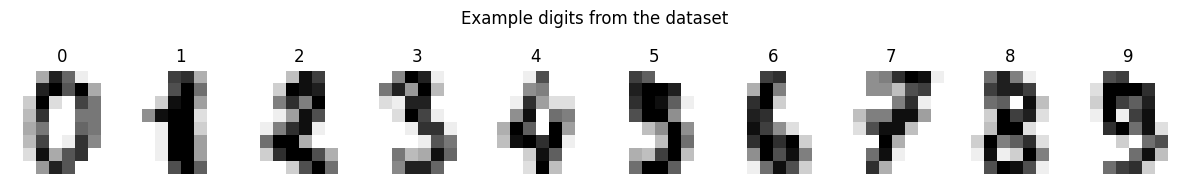

Total digits: 1797
Training: 1437  |  Testing: 360
Each digit has 64 features (one per pixel)
✓ Data loaded


In [2]:
# Load the digits dataset
digits = load_digits()

# Show some example digits
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(digits.target[i])
    ax.axis("off")
plt.suptitle("Example digits from the dataset")
plt.tight_layout()
plt.show()

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

print(f"Total digits: {len(digits.data)}")
print(f"Training: {len(X_train)}  |  Testing: {len(X_test)}")
print(f"Each digit has {digits.data.shape[1]} features (one per pixel)")
print("✓ Data loaded")

<div class="alert alert-info">

### 👀 What are we looking at?

Each image is tiny — just 8×8 pixels. But that's enough for a model to learn the patterns that distinguish a "3" from an "8". With 10 possible classes and messy handwriting, this is much harder than the 3-species iris problem.

</div>

---

## <span style="color: purple;">Step 2 — Try a single decision tree</span>

Let's start with a single decision tree, just like in Lesson 7.

<div class="alert alert-info">

**Run the next cell** to train a decision tree and see how it does.

</div>

In [3]:
# Train a single decision tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

tree_acc = accuracy_score(y_test, tree.predict(X_test)) * 100
print(f"Single decision tree accuracy: {tree_acc:.1f}%")
print("✓ Decision tree trained")

Single decision tree accuracy: 84.2%
✓ Decision tree trained


<div class="alert alert-info">

### 👀 Not bad, but not great

Around 85% means the tree is getting roughly 1 in 7 digits wrong. Can we do better by combining many trees?

</div>

---

## <span style="color: purple;">Step 3 — Train a random forest</span>

Now let's train a random forest with 100 trees and compare.

<div class="alert alert-info">

**Run the next cell** to train the forest.

</div>

In [4]:
# Train a random forest with 100 trees
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

forest_acc = accuracy_score(y_test, forest.predict(X_test)) * 100

print(f"Single decision tree: {tree_acc:.1f}%")
print(f"Random forest (100 trees): {forest_acc:.1f}%")
print(f"Improvement: +{forest_acc - tree_acc:.1f}%")
print("✓ Random forest trained")

Single decision tree: 84.2%
Random forest (100 trees): 97.2%
Improvement: +13.1%
✓ Random forest trained


<div class="alert alert-info">

### 👀 That's a big jump

The random forest got a much higher accuracy by combining 100 trees. Each individual tree might make mistakes, but they make **different** mistakes — so when they vote together, the errors cancel out.

</div>

---

## <span style="color: purple;">Step 4 — See the mistakes</span>

Let's look at some digits that the single tree got wrong but the forest got right.

<div class="alert alert-info">

**Run the next cell** to see them.

</div>

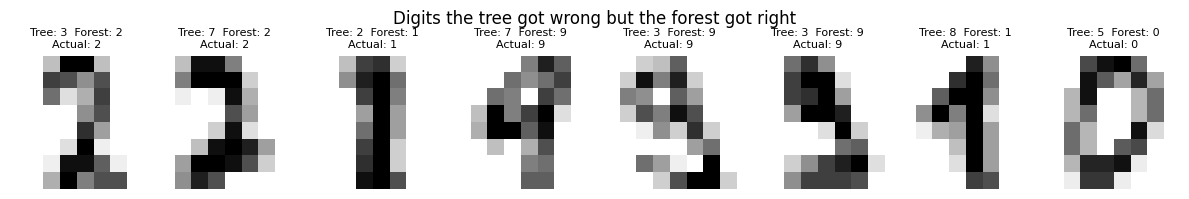

✓ Mistakes shown


In [5]:
# Find digits that the tree got wrong but the forest got right
tree_pred = tree.predict(X_test)
forest_pred = forest.predict(X_test)

tree_wrong = tree_pred != y_test
forest_right = forest_pred == y_test
fixed = np.where(tree_wrong & forest_right)[0]

# Show up to 8 of them
n_show = min(8, len(fixed))
fig, axes = plt.subplots(1, n_show, figsize=(12, 2))
for i, ax in enumerate(axes):
    idx = fixed[i]
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Tree: {tree_pred[idx]}  Forest: {forest_pred[idx]}\nActual: {y_test[idx]}", fontsize=8)
    ax.axis("off")
plt.suptitle("Digits the tree got wrong but the forest got right")
plt.tight_layout()
plt.show()
print("✓ Mistakes shown")

---

## <span style="color: purple;">🧠 What did we just do?</span>

We moved to a harder dataset — handwritten digits — where a single decision tree struggled. By training a random forest (100 trees that each see slightly different data and vote together), we got a much more accurate model.

The key idea is **ensemble learning**: combining many simple models often beats one complex model. Random forests are popular in practice because they work well, are hard to overfit, and need very little tuning.

---

### Key words

| Word | What it means |
|------|--------------:|
| **Random Forest** | Many decision trees that vote together on the prediction |
| **Ensemble** | Combining multiple models to get a better result |

---

## <span style="color: purple;">🔧 Your turn!</span>

We used 100 trees, but do you really need that many? More trees means more time to train.

**Change `n_trees` below to find the fewest trees needed to beat 95% accuracy.**

In [ ]:
# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼  CHANGE THIS  ▼▼▼▼▼▼▼▼▼▼▼▼▼▼
n_trees = 100   # ← try 1, 5, 10, 25, 50, 100
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲  CHANGE THIS  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲

my_forest = RandomForestClassifier(n_estimators=n_trees, random_state=42)
my_forest.fit(X_train, y_train)

my_acc = accuracy_score(y_test, my_forest.predict(X_test)) * 100
print(f"{n_trees} trees → Accuracy: {my_acc:.1f}%")

if my_acc > 95:
    print("Above 95% — nice!")
else:
    print("Below 95% — try adding more trees.")
print("✓ Your forest trained")

10 trees → Accuracy: 95.8%
Above 95% — nice!
✓ Your forest trained


---

## <span style="color: purple;">🧪 Quick Quiz</span>

Test yourself on what you just learned. Run the code cell, select your answer for each question, then click **Check answers**.

In [7]:
from quiz import run_b08_quiz
run_b08_quiz()